In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [15]:
iris = load_iris()
X = iris.data
y = iris.target
print("Original Shape:", X.shape)


Original Shape: (150, 4)


In [16]:
mask = y < 2
X = X[mask]
y = y[mask]

print("Binary Shape:", X.shape)


Binary Shape: (100, 4)


In [17]:
y = np.where(y == 0, -1, 1)

print("Sample Labels:", y[:10])


Sample Labels: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [18]:
# Artificially enlarge petal length feature
X[:,2] = X[:,2] * 100

print("Sample Data:\n", X[:5])


Sample Data:
 [[  5.1   3.5 140.    0.2]
 [  4.9   3.  140.    0.2]
 [  4.7   3.2 130.    0.2]
 [  4.6   3.1 150.    0.2]
 [  5.    3.6 140.    0.2]]


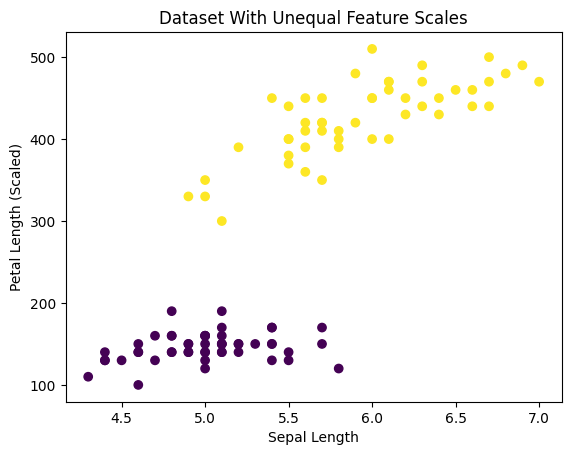

In [19]:
plt.scatter(X[:,0], X[:,2], c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length (Scaled)")
plt.title("Dataset With Unequal Feature Scales")
plt.show()


In [20]:
class Perceptron:
    
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.errors = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                
                if target * (np.dot(xi, self.w) + self.b) <= 0:
                    self.w += self.lr * target * xi
                    self.b += self.lr * target
                    error_count += 1

            self.errors.append(error_count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)


In [21]:
p1 = Perceptron(lr=0.0001, epochs=50)
p1.fit(X, y)


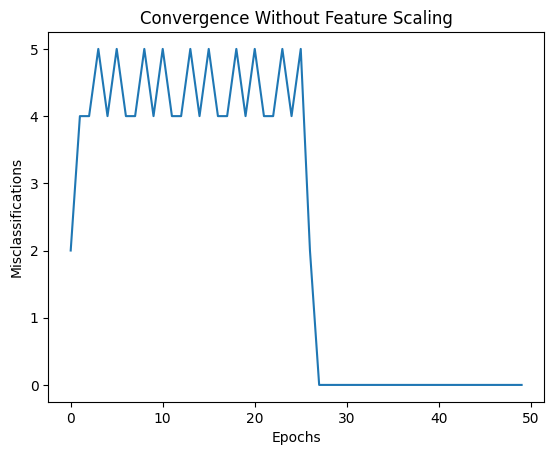

In [22]:
plt.plot(p1.errors)
plt.title("Convergence Without Feature Scaling")
plt.xlabel("Epochs")
plt.ylabel("Misclassifications")
plt.show()


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Sample Data:\n", X_scaled[:5])


Scaled Sample Data:
 [[-0.5810659   0.84183714 -1.01297765 -1.04211089]
 [-0.89430898 -0.2078351  -1.01297765 -1.04211089]
 [-1.20755205  0.21203379 -1.08231219 -1.04211089]
 [-1.36417359  0.00209934 -0.94364311 -1.04211089]
 [-0.73768744  1.05177159 -1.01297765 -1.04211089]]


In [24]:
p2 = Perceptron(lr=0.01, epochs=50)
p2.fit(X_scaled, y)


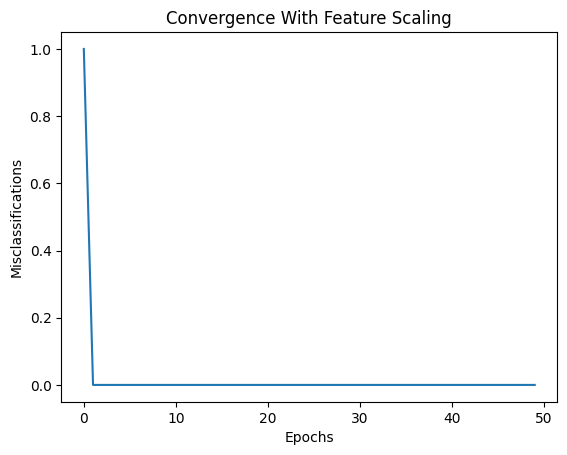

In [25]:
plt.plot(p2.errors)
plt.title("Convergence With Feature Scaling")
plt.xlabel("Epochs")
plt.ylabel("Misclassifications")
plt.show()


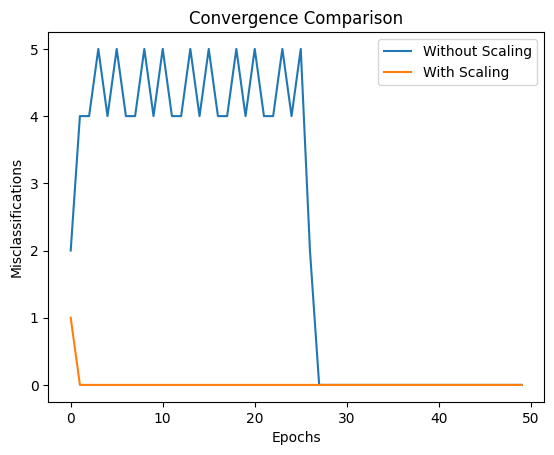

In [26]:
plt.plot(p1.errors, label="Without Scaling")
plt.plot(p2.errors, label="With Scaling")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Misclassifications")
plt.title("Convergence Comparison")
plt.show()


In [27]:
def accuracy(model, X, y):
    pred = model.predict(X)
    return np.mean(pred == y)

print("Accuracy Without Scaling:", accuracy(p1, X, y))
print("Accuracy With Scaling:", accuracy(p2, X_scaled, y))


Accuracy Without Scaling: 1.0
Accuracy With Scaling: 1.0
